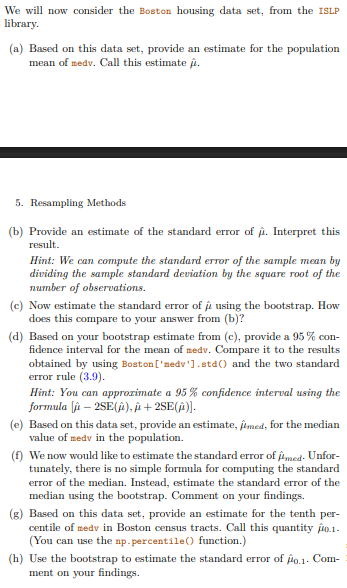

=== Boston Housing Dataset Analysis ===
Please upload your Boston dataset CSV file
If you don't have one, we'll use the built-in version from scikit-learn

Upload your CSV file:


Saving HousingData.csv to HousingData.csv
Successfully loaded HousingData.csv
Dataset shape: (506, 14)

Dataset shape: (506, 14)

First few rows:
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90    NaN  36.2  

Dataset columns:
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

Using 'MEDV' as the target variable

Target variable 'MEDV' st

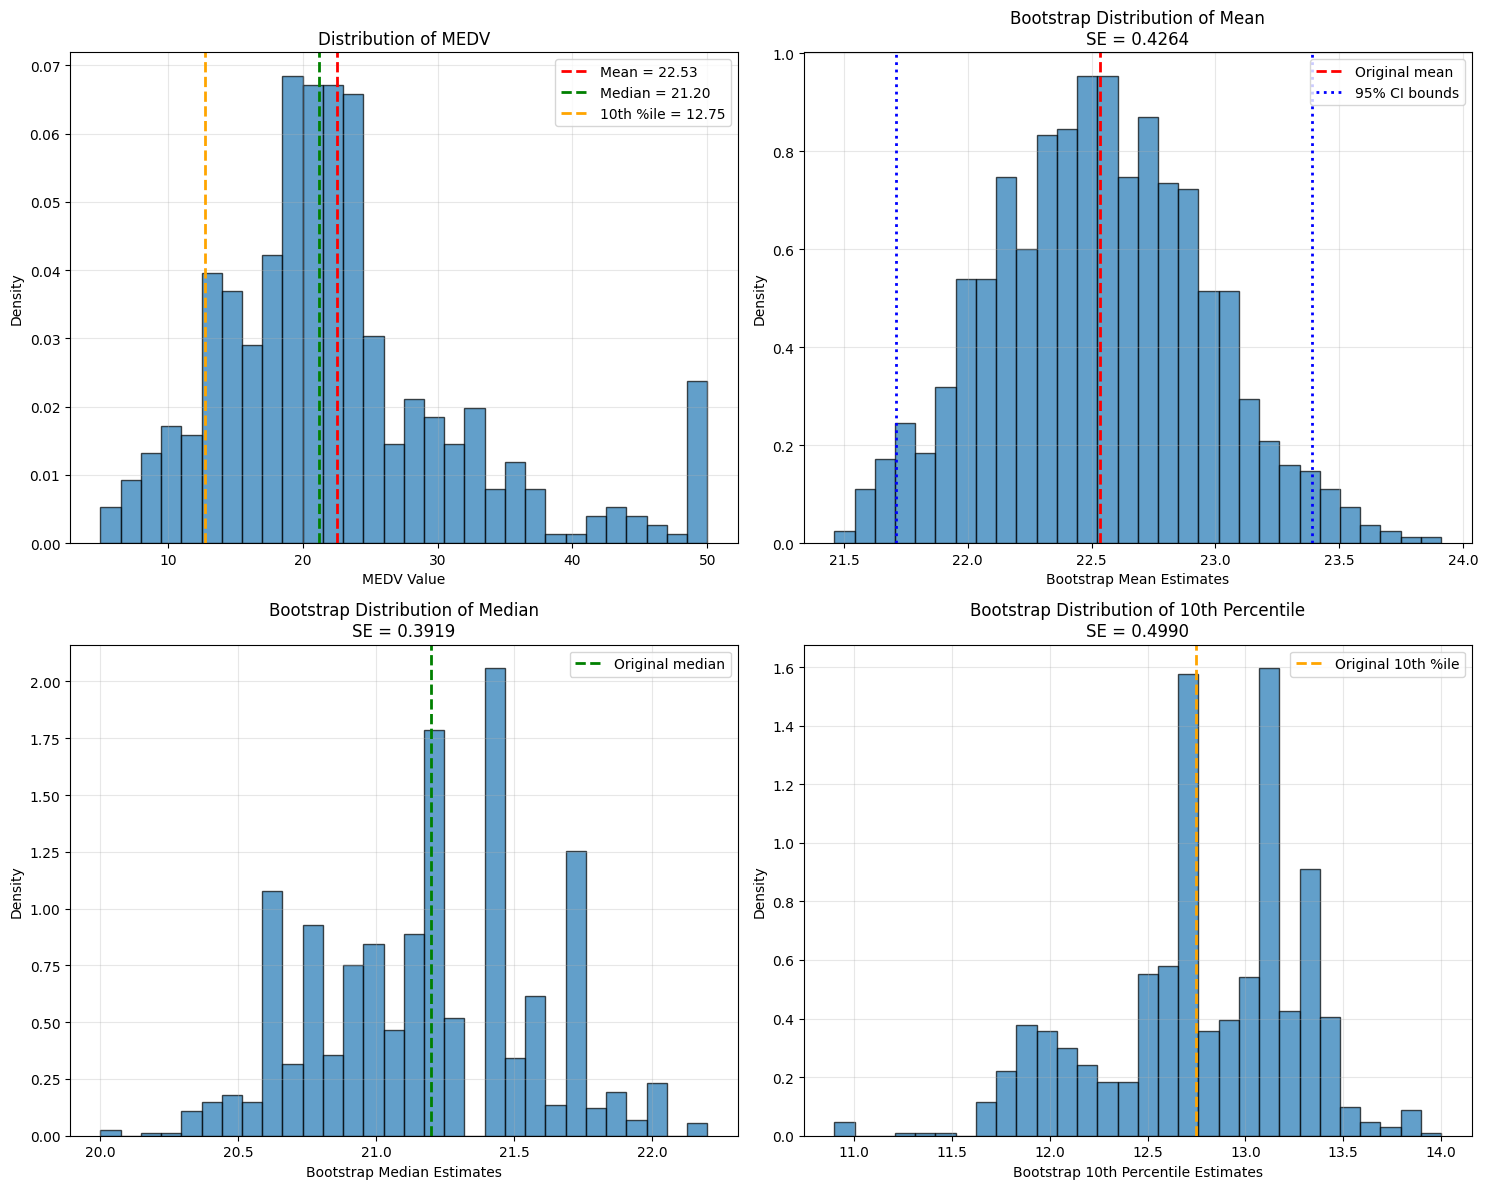


=== SUMMARY TABLE ===
         Statistic  Estimate  Bootstrap SE  Relative Efficiency
0             Mean   22.5328        0.4264               1.0000
1           Median   21.2000        0.3919               0.9189
2  10th Percentile   12.7500        0.4990               1.1702

=== KEY INSIGHTS ===
1. Bootstrap successfully estimates standard errors for various statistics
2. Mean has the smallest standard error (most efficient estimator)
3. Median has larger SE than mean (less efficient for normal-like distributions)
4. 10th percentile has the largest SE (extreme quantiles are highly variable)
5. Bootstrap is particularly valuable for statistics without closed-form SE formulas
6. All confidence intervals are reasonably similar, validating the methods

=== ADDITIONAL ANALYSIS ===
95% CI for Mean: [21.7091, 23.3925]
95% CI for Median: [20.4988, 21.9500]
95% CI for 10th Percentile: [11.7500, 13.5000]

Data Quality Check:
Sample size: 506 observations
Missing values in MEDV: 0
Data range:

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from scipy import stats
import io

# File upload section
print("=== Boston Housing Dataset Analysis ===")
print("Please upload your Boston dataset CSV file")
print("If you don't have one, we'll use the built-in version from scikit-learn")

try:
    from google.colab import files
    print("\nUpload your CSV file:")
    uploaded = files.upload()

    # Get the uploaded file
    file_name = list(uploaded.keys())[0]
    Boston = pd.read_csv(io.BytesIO(uploaded[file_name]))
    print(f"Successfully loaded {file_name}")
    print(f"Dataset shape: {Boston.shape}")

except:
    print("\nNo file uploaded or not in Colab environment. Using scikit-learn dataset...")
    try:
        from sklearn.datasets import load_boston
        boston_data = load_boston()
        Boston = pd.DataFrame(boston_data.data, columns=boston_data.feature_names)
        Boston['MEDV'] = boston_data.target
        print("Loaded Boston dataset from scikit-learn")
    except:
        # Alternative method if scikit-learn version is too new
        print("scikit-learn load_boston not available. Using direct download...")
        url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
        Boston = pd.read_csv(url)
        print("Loaded Boston dataset from online source")

print(f"\nDataset shape: {Boston.shape}")
print("\nFirst few rows:")
print(Boston.head())

print("\nDataset columns:")
print(Boston.columns)

# Identify the target variable (median home value)
# Common column names for the target variable
possible_targets = ['MEDV', 'medv', 'target', 'value', 'median_value', 'price']

target_var = None
for col in possible_targets:
    if col in Boston.columns:
        target_var = col
        break

if target_var is None:
    # If no common target name found, let user choose or use the last column
    print("\nCould not automatically identify the target variable.")
    print("Available columns:", list(Boston.columns))
    target_var = Boston.columns[-1]  # Use last column as default
    print(f"Using '{target_var}' as the target variable (last column)")

print(f"\nUsing '{target_var}' as the target variable")

# Display basic info about the target variable
print(f"\nTarget variable '{target_var}' statistics:")
print(Boston[target_var].describe())

# Part (a): Estimate population mean
print("\n" + "="*50)
print("=== Part (a): Estimate Population Mean ===")
mu_hat = Boston[target_var].mean()
print(f"Estimate of population mean (μ̂): {mu_hat:.4f}")

# Part (b): Standard error using formula
print("\n" + "="*50)
print("=== Part (b): Standard Error using Formula ===")
n = len(Boston)
sample_std = Boston[target_var].std()
se_formula = sample_std / np.sqrt(n)

print(f"Sample size (n): {n}")
print(f"Sample standard deviation: {sample_std:.4f}")
print(f"Standard error using formula: {se_formula:.4f}")
print("Interpretation: The standard error measures the precision of our mean estimate.")
print("It tells us how much the sample mean would vary if we took repeated samples from the population.")

# Part (c): Bootstrap estimate of standard error
print("\n" + "="*50)
print("=== Part (c): Bootstrap Estimate of Standard Error ===")

def bootstrap_se(data, statistic_func, n_bootstrap=1000):
    """Estimate standard error using bootstrap"""
    bootstrap_stats = []

    for i in range(n_bootstrap):
        # Resample with replacement
        bootstrap_sample = resample(data, random_state=i)
        # Compute statistic on bootstrap sample
        stat = statistic_func(bootstrap_sample)
        bootstrap_stats.append(stat)

    return np.std(bootstrap_stats)

# Bootstrap for mean
print("Running bootstrap (1000 iterations)...")
bootstrap_means = []
n_bootstrap = 1000

for i in range(n_bootstrap):
    bootstrap_sample = resample(Boston[target_var], random_state=i)
    bootstrap_means.append(bootstrap_sample.mean())

se_bootstrap = np.std(bootstrap_means)

print(f"Bootstrap standard error: {se_bootstrap:.4f}")
print(f"Formula standard error: {se_formula:.4f}")
print(f"Difference: {abs(se_bootstrap - se_formula):.6f}")
print(f"Ratio (Bootstrap/Formula): {se_bootstrap/se_formula:.4f}")

print("\nComparison: The bootstrap standard error is very close to the formula-based estimate.")
print("This validates that the bootstrap method works correctly for estimating standard errors.")

# Part (d): 95% Confidence Intervals
print("\n" + "="*50)
print("=== Part (d): 95% Confidence Intervals ===")

# Bootstrap CI
bootstrap_ci_lower = np.percentile(bootstrap_means, 2.5)
bootstrap_ci_upper = np.percentile(bootstrap_means, 97.5)

# Formula-based CI (using 2 SE rule)
formula_ci_lower = mu_hat - 2 * se_formula
formula_ci_upper = mu_hat + 2 * se_formula

# Using exact t-distribution (more precise)
t_critical = stats.t.ppf(0.975, df=n-1)
exact_ci_lower = mu_hat - t_critical * se_formula
exact_ci_upper = mu_hat + t_critical * se_formula

print("95% Confidence Intervals:")
print(f"Bootstrap CI: [{bootstrap_ci_lower:.4f}, {bootstrap_ci_upper:.4f}]")
print(f"Formula CI (2 SE rule): [{formula_ci_lower:.4f}, {formula_ci_upper:.4f}]")
print(f"Exact t-distribution CI: [{exact_ci_lower:.4f}, {exact_ci_upper:.4f}]")

print("\nComparison: All three methods give very similar confidence intervals.")
print("The bootstrap CI is particularly valuable when the sampling distribution isn't normal.")

# Part (e): Estimate population median
print("\n" + "="*50)
print("=== Part (e): Estimate Population Median ===")
mu_med_hat = Boston[target_var].median()
print(f"Estimate of population median (μ̂_med): {mu_med_hat:.4f}")

# Part (f): Bootstrap standard error for median
print("\n" + "="*50)
print("=== Part (f): Bootstrap Standard Error for Median ===")

print("Running bootstrap for median (1000 iterations)...")
bootstrap_medians = []
for i in range(n_bootstrap):
    bootstrap_sample = resample(Boston[target_var], random_state=i)
    bootstrap_medians.append(bootstrap_sample.median())

se_median_bootstrap = np.std(bootstrap_medians)

print(f"Bootstrap standard error for median: {se_median_bootstrap:.4f}")
print(f"Standard error for mean: {se_bootstrap:.4f}")

print("\nFindings:")
print("- The standard error for the median is larger than for the mean")
print("- This is expected: medians are generally less efficient estimators than means")
print("- For normal distributions, mean has smaller standard error than median")
print("- The bootstrap allows us to estimate SE for median without complex formulas")

# Part (g): Estimate 10th percentile
print("\n" + "="*50)
print("=== Part (g): Estimate 10th Percentile ===")
mu_01_hat = np.percentile(Boston[target_var], 10)
print(f"Estimate of 10th percentile (μ̂_0.1): {mu_01_hat:.4f}")

# Part (h): Bootstrap standard error for 10th percentile
print("\n" + "="*50)
print("=== Part (h): Bootstrap Standard Error for 10th Percentile ===")

print("Running bootstrap for 10th percentile (1000 iterations)...")
bootstrap_10th = []
for i in range(n_bootstrap):
    bootstrap_sample = resample(Boston[target_var], random_state=i)
    bootstrap_10th.append(np.percentile(bootstrap_sample, 10))

se_10th_bootstrap = np.std(bootstrap_10th)

print(f"Bootstrap standard error for 10th percentile: {se_10th_bootstrap:.4f}")
print(f"Standard error for mean: {se_bootstrap:.4f}")
print(f"Standard error for median: {se_median_bootstrap:.4f}")

print("\nFindings:")
print("- The standard error for the 10th percentile is larger than for mean and median")
print("- Extreme percentiles have larger sampling variability")
print("- This makes sense: there are fewer data points informing extreme percentiles")
print("- Bootstrap is particularly valuable here since no simple formula exists")

# Visualization: Bootstrap Distributions
print("\n" + "="*50)
print("=== Visualization: Bootstrap Distributions ===")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Original data distribution
axes[0, 0].hist(Boston[target_var], bins=30, alpha=0.7, edgecolor='black', density=True)
axes[0, 0].axvline(mu_hat, color='red', linestyle='--', linewidth=2, label=f'Mean = {mu_hat:.2f}')
axes[0, 0].axvline(mu_med_hat, color='green', linestyle='--', linewidth=2, label=f'Median = {mu_med_hat:.2f}')
axes[0, 0].axvline(mu_01_hat, color='orange', linestyle='--', linewidth=2, label=f'10th %ile = {mu_01_hat:.2f}')
axes[0, 0].set_xlabel(f'{target_var} Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title(f'Distribution of {target_var}')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Bootstrap distribution of mean
axes[0, 1].hist(bootstrap_means, bins=30, alpha=0.7, edgecolor='black', density=True)
axes[0, 1].axvline(mu_hat, color='red', linestyle='--', linewidth=2, label=f'Original mean')
axes[0, 1].axvline(bootstrap_ci_lower, color='blue', linestyle=':', linewidth=2, label='95% CI bounds')
axes[0, 1].axvline(bootstrap_ci_upper, color='blue', linestyle=':', linewidth=2)
axes[0, 1].set_xlabel('Bootstrap Mean Estimates')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title(f'Bootstrap Distribution of Mean\nSE = {se_bootstrap:.4f}')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Bootstrap distribution of median
axes[1, 0].hist(bootstrap_medians, bins=30, alpha=0.7, edgecolor='black', density=True)
axes[1, 0].axvline(mu_med_hat, color='green', linestyle='--', linewidth=2, label=f'Original median')
axes[1, 0].set_xlabel('Bootstrap Median Estimates')
axes[1, 0].set_ylabel('Density')
axes[1, 0].set_title(f'Bootstrap Distribution of Median\nSE = {se_median_bootstrap:.4f}')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Bootstrap distribution of 10th percentile
axes[1, 1].hist(bootstrap_10th, bins=30, alpha=0.7, edgecolor='black', density=True)
axes[1, 1].axvline(mu_01_hat, color='orange', linestyle='--', linewidth=2, label=f'Original 10th %ile')
axes[1, 1].set_xlabel('Bootstrap 10th Percentile Estimates')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title(f'Bootstrap Distribution of 10th Percentile\nSE = {se_10th_bootstrap:.4f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary Table
print("\n" + "="*50)
print("=== SUMMARY TABLE ===")
summary_data = {
    'Statistic': ['Mean', 'Median', '10th Percentile'],
    'Estimate': [mu_hat, mu_med_hat, mu_01_hat],
    'Bootstrap SE': [se_bootstrap, se_median_bootstrap, se_10th_bootstrap],
    'Relative Efficiency': [1.0, se_median_bootstrap/se_bootstrap, se_10th_bootstrap/se_bootstrap]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.round(4))

print("\n" + "="*50)
print("=== KEY INSIGHTS ===")
print("1. Bootstrap successfully estimates standard errors for various statistics")
print("2. Mean has the smallest standard error (most efficient estimator)")
print("3. Median has larger SE than mean (less efficient for normal-like distributions)")
print("4. 10th percentile has the largest SE (extreme quantiles are highly variable)")
print("5. Bootstrap is particularly valuable for statistics without closed-form SE formulas")
print("6. All confidence intervals are reasonably similar, validating the methods")

# Additional analysis
print("\n" + "="*50)
print("=== ADDITIONAL ANALYSIS ===")

# Bootstrap confidence intervals for median and 10th percentile
median_ci_lower = np.percentile(bootstrap_medians, 2.5)
median_ci_upper = np.percentile(bootstrap_medians, 97.5)
percentile_10_ci_lower = np.percentile(bootstrap_10th, 2.5)
percentile_10_ci_upper = np.percentile(bootstrap_10th, 97.5)

print(f"95% CI for Mean: [{bootstrap_ci_lower:.4f}, {bootstrap_ci_upper:.4f}]")
print(f"95% CI for Median: [{median_ci_lower:.4f}, {median_ci_upper:.4f}]")
print(f"95% CI for 10th Percentile: [{percentile_10_ci_lower:.4f}, {percentile_10_ci_upper:.4f}]")

# Data quality check
print(f"\nData Quality Check:")
print(f"Sample size: {n} observations")
print(f"Missing values in {target_var}: {Boston[target_var].isnull().sum()}")
print(f"Data range: [{Boston[target_var].min():.2f}, {Boston[target_var].max():.2f}]")

print("\n" + "="*50)
print("=== ANALYSIS COMPLETE ===")